# 🌸 Iris Dataset — EDA + Decision Tree Classifier

**Name:** Bandari Ravi Prakash
**College:** Vidya Jyothi Institute of Technology
**Course:** B.Tech CSE — 2nd Year

---

### 📌 About this Project

The Iris dataset contains 150 flower samples from 3 species —
Setosa, Versicolor, and Virginica — with 4 features each:
sepal length, sepal width, petal length, and petal width.

In this notebook I have performed:
- Full Exploratory Data Analysis (EDA)
- Decision Tree Classification
- Model Evaluation and Feature Importance

## 📦 Step 1 — Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import  seaborn as sns

## 📂 Step 2 — Load Dataset

Loading the Iris dataset directly using Seaborn.
The dataset has:
- 150 rows and 5 columns
- 4 numeric feature columns
- 1 target column — species (Setosa, Versicolor, Virginica)

In [2]:
df = sns.load_dataset("iris")

In [3]:
df


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


## 🔍 Step 3 — Basic Inspection

Checking the shape, data types, and first few rows of the dataset.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


## 📊 Step 4 — Class Distribution

Checking how many samples exist per species.
A balanced dataset means equal samples per class — important for fair model training.

In [5]:
df["species"].value_counts()

,count
species,
setosa,50
versicolor,50
virginica,50


## 🧹 Step 5 — Data Quality Check

Checking for:
- Missing values — any null or NaN entries
- Duplicate rows — repeated records

Clean data = reliable analysis.

In [6]:
df.isnull().sum().sum()

np.int64(0)

In [7]:
df.duplicated().sum()

np.int64(1)

In [8]:
df.drop_duplicates(inplace=True)

## 📈 Step 6 — Descriptive Statistics

Checking the mean, standard deviation, min, and max
for each feature — both overall and grouped by species.

This helps us understand:
- The range of each feature
- How different each species is on average

In [9]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,149.000000,149.000000,149.000000,149.000000
mean,5.843624,3.059732,3.748993,1.194631
std,0.830851,0.436342,1.767791,0.762622
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.300000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [10]:
df.groupby("species").mean()


,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.006000,3.428000,1.462000,0.246000
versicolor,5.936000,2.770000,4.260000,1.326000
virginica,6.604082,2.979592,5.561224,2.028571


In [11]:
df.groupby("species").std()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,0.352490,0.379064,0.173664,0.105386
versicolor,0.516171,0.313798,0.469911,0.197753
virginica,0.632113,0.323380,0.553706,0.276887


In [12]:
dum=df.drop("species",axis=1)
dum

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


## 📦 Step 7 — Boxplots

Boxplots show the distribution of each feature per species.

What to look for:
- The box = middle 50% of the data (IQR)
- The line inside = median
- Dots outside the whiskers = outliers

Observation:
- Petal features show clear separation between species
- Sepal width shows heavy overlap — weakest feature

/tmp/ipykernel_2953/635341732.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=col, palette='Set2')


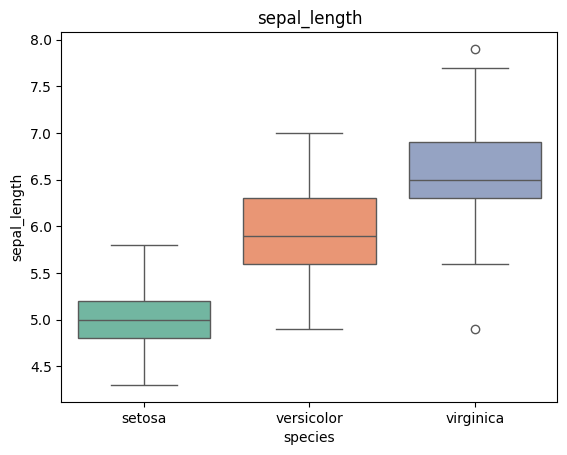

/tmp/ipykernel_2953/635341732.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=col, palette='Set2')


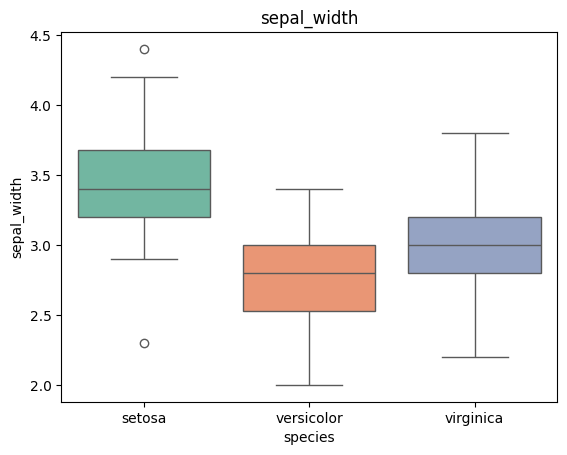

/tmp/ipykernel_2953/635341732.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=col, palette='Set2')


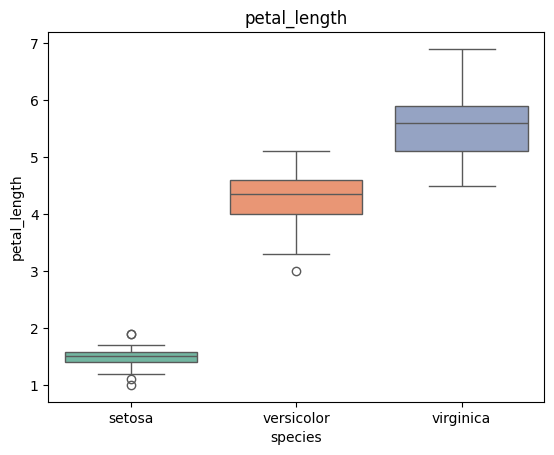

/tmp/ipykernel_2953/635341732.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=col, palette='Set2')


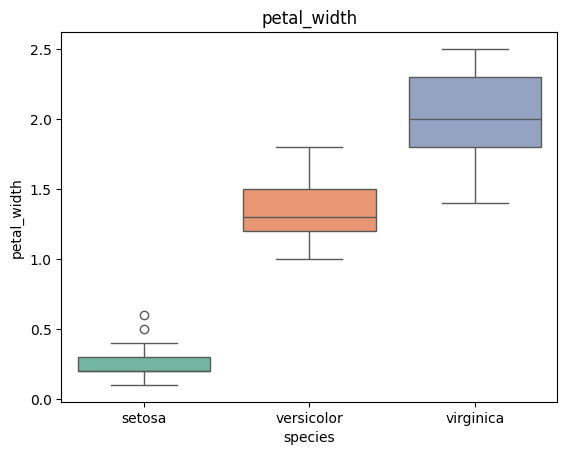

In [13]:
for col in dum.columns:
    sns.boxplot(data=df, x='species', y=col, palette='Set2')
    plt.title(col)
    plt.show()

## 🔗 Step 8 — Pairplot

Pairplot shows every feature combination plotted against each other,
colored by species.

This is the most informative single visualization for this dataset.

Observation:
- Setosa (top-left cluster) is clearly separated in petal plots
- Versicolor and Virginica overlap slightly
- Petal length vs petal width gives the best visual separation

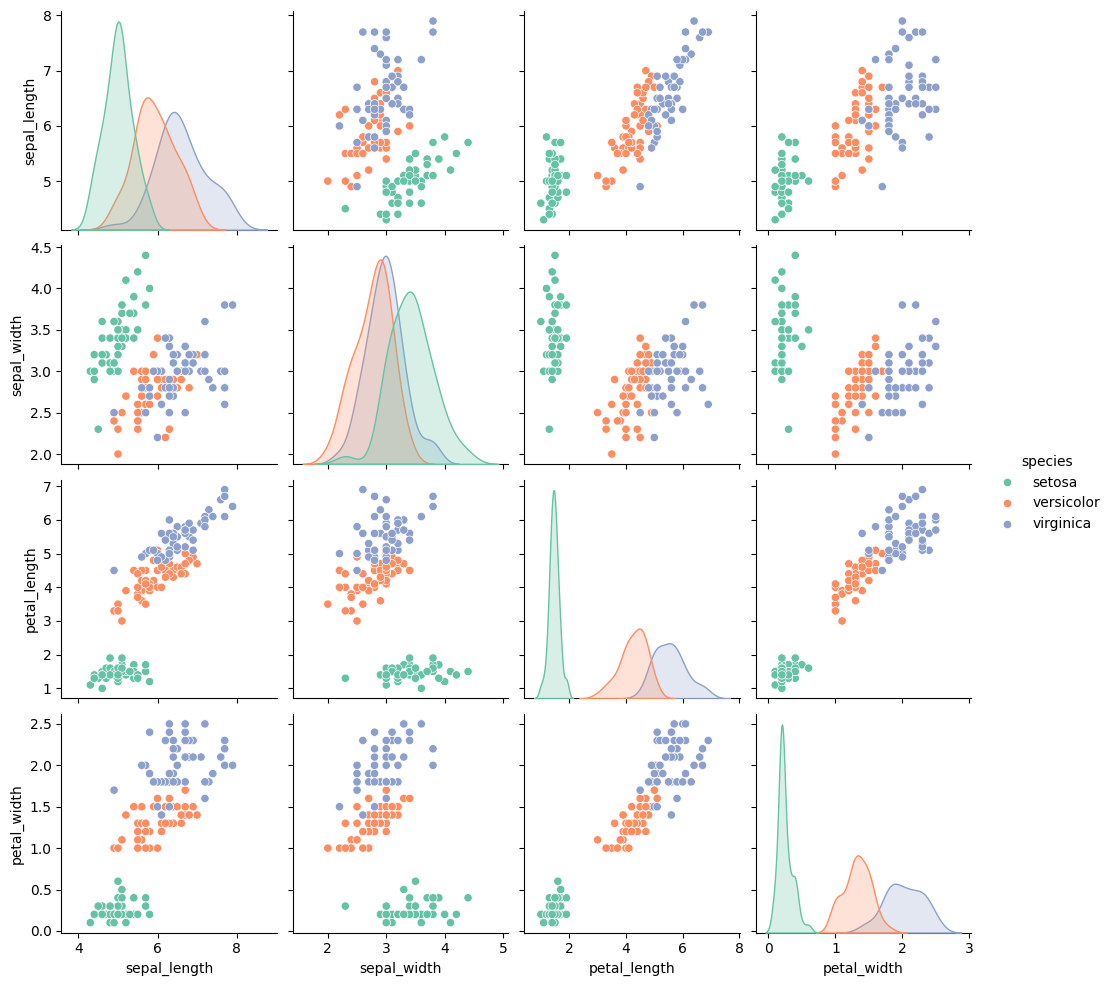

In [14]:
sns.pairplot(df,hue="species" , palette="Set2",diag_kind="kde")
plt.show()

## 🎯 Step 9 — Best Separating Features (Scatter Plot)

Plotting petal length vs petal width — the two features
that best separate all 3 species visually.

Observation:
- Setosa forms a completely separate cluster (bottom left)
- Versicolor is in the middle
- Virginica is at the top right
- Only a tiny overlap between Versicolor and Virginica

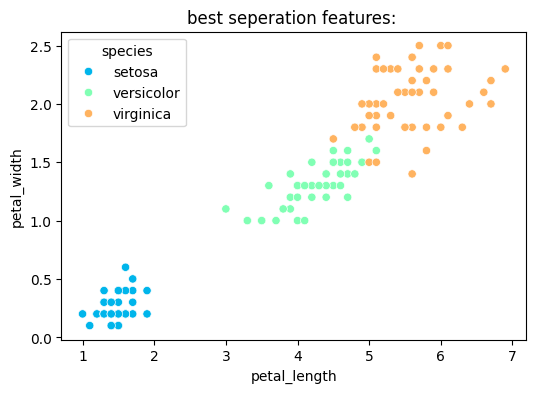

In [15]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df , x="petal_length" , y="petal_width",hue="species",palette="rainbow")
plt.title("best seperation features: ")
plt.show()

## 🌡️ Step 10 — Correlation Heatmap

Correlation tells us how strongly two features move together.
- Value close to +1 = strong positive correlation
- Value close to -1 = strong negative correlation
- Value close to 0 = no relationship

Observation:
- Petal length and petal width are 96% correlated
- Sepal width has near zero or negative correlation with others
- High correlation means these two features carry similar information

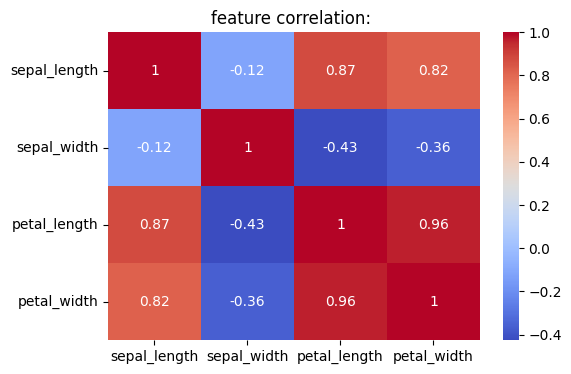

In [16]:
corr=df.drop("species",axis=1)
plt.figure(figsize=(6,4))
sns.heatmap(corr.corr(),annot=True,cmap="coolwarm")
plt.title("feature correlation: ")
plt.show()

## 🎻 Step 11 — Violin Plots

Violin plots combine a boxplot and a KDE curve together.
They show the full distribution shape of each feature per species.

Observation:
- Setosa has a very narrow violin for petal features = very consistent
- Virginica has a wider violin = more variation
- Petal features show 3 clearly separate violins = great for classification
- Sepal width violins heavily overlap = poor feature for classification

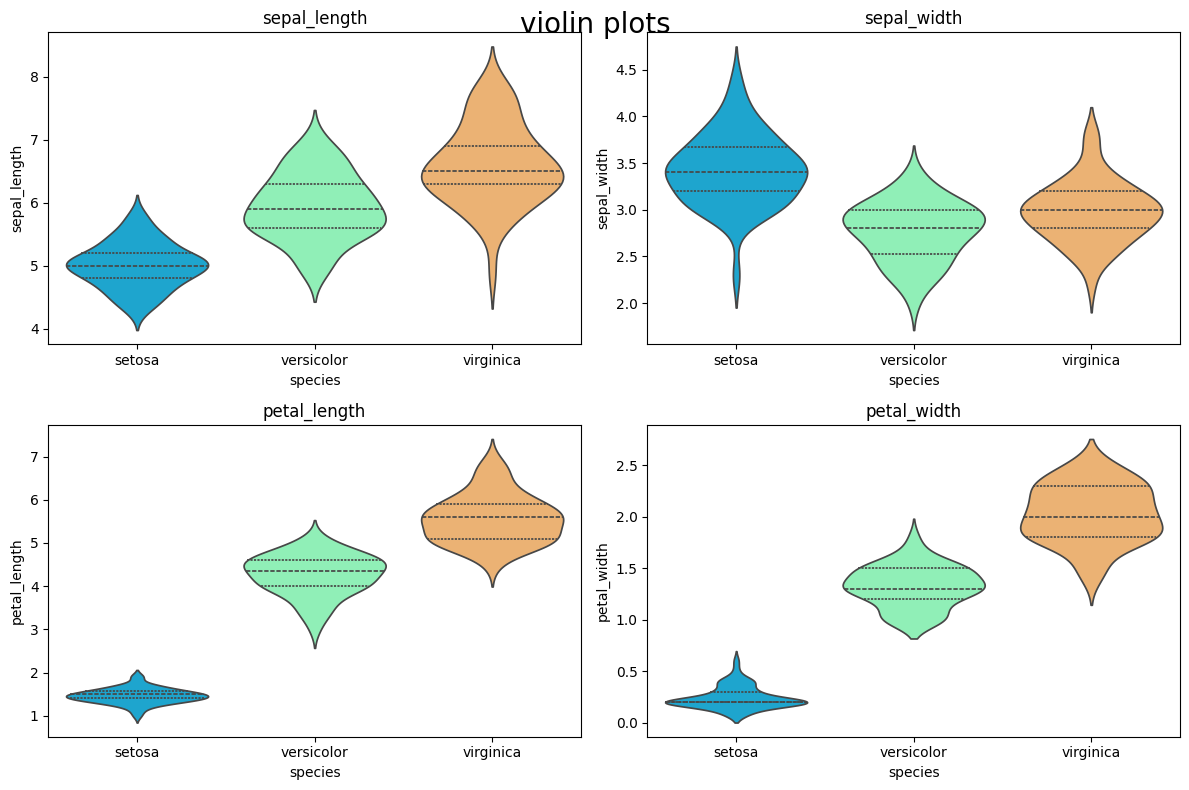

In [17]:
fig,axes = plt.subplots(2,2,figsize=(12,8))
sns.violinplot(data=df,x="species",y="sepal_length",hue="species", ax=axes[0][0],inner='quartile',palette="rainbow")
sns.violinplot(data=df,x="species",y="sepal_width",hue="species",ax=axes[0][1],inner='quartile',palette="rainbow")
sns.violinplot(data=df,x="species",y="petal_length",hue="species",ax=axes[1][0],inner='quartile',palette="rainbow")
sns.violinplot(data=df,x="species",y="petal_width",hue="species",ax=axes[1][1],inner='quartile',palette="rainbow")
axes[0][0].set_title("sepal_length")
axes[0][1].set_title("sepal_width")
axes[1][0].set_title("petal_length")
axes[1][1].set_title("petal_width")
plt.tight_layout()
plt.suptitle("violin plots",fontsize="20")
plt.show()


## 📊 Step 12 — Bar Plots

Bar plots show the average (mean) value of each feature per species.
Useful for a quick comparison of which species has higher or lower values on average.

Observation:
- Virginica has the highest average petal length and petal width
- Setosa has the smallest petal values but the widest sepals

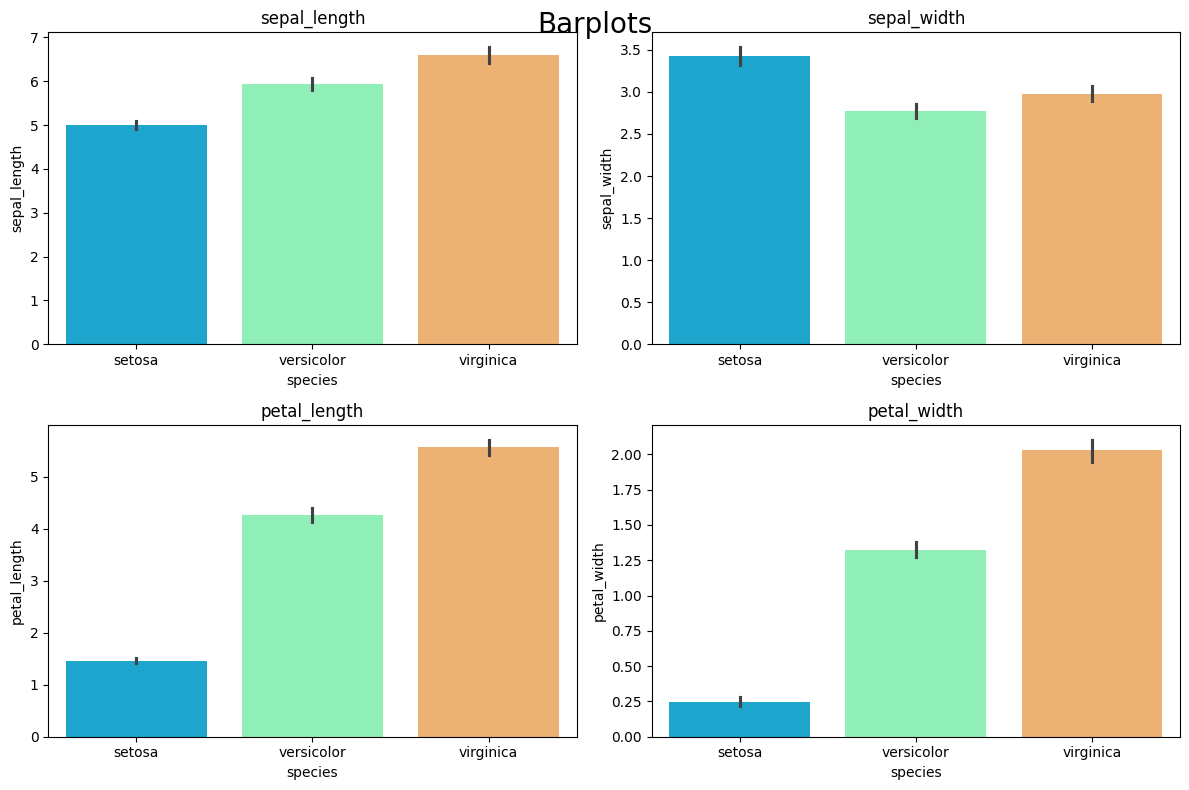

In [18]:
fig,axes = plt.subplots(2,2,figsize=(12,8))
sns.barplot(data=df,x="species",y="sepal_width",hue="species",ax=axes[0][1],palette="rainbow")
sns.barplot(data=df,x="species",y="petal_length",hue="species",ax=axes[1][0],palette="rainbow")
sns.barplot(data=df,x="species",y="sepal_length",hue="species", ax=axes[0][0],palette="rainbow")
sns.barplot(data=df,x="species",y="petal_width",hue="species",ax=axes[1][1],palette="rainbow")
axes[0][0].set_title("sepal_length")
axes[0][1].set_title("sepal_width")
axes[1][0].set_title("petal_length")
axes[1][1].set_title("petal_width")
plt.tight_layout()
plt.suptitle("Barplots",fontsize="20")
plt.show()

## 📉 Step 13 — Histplots (with KDE)

Histograms show how frequently each value appears in the dataset.
KDE (the smooth curve on top) shows the overall distribution shape.

Observation:
- Petal histograms show 3 clearly separated peaks — one per species
- Sepal histograms show heavily overlapping peaks
- This confirms petal features are far better for classification

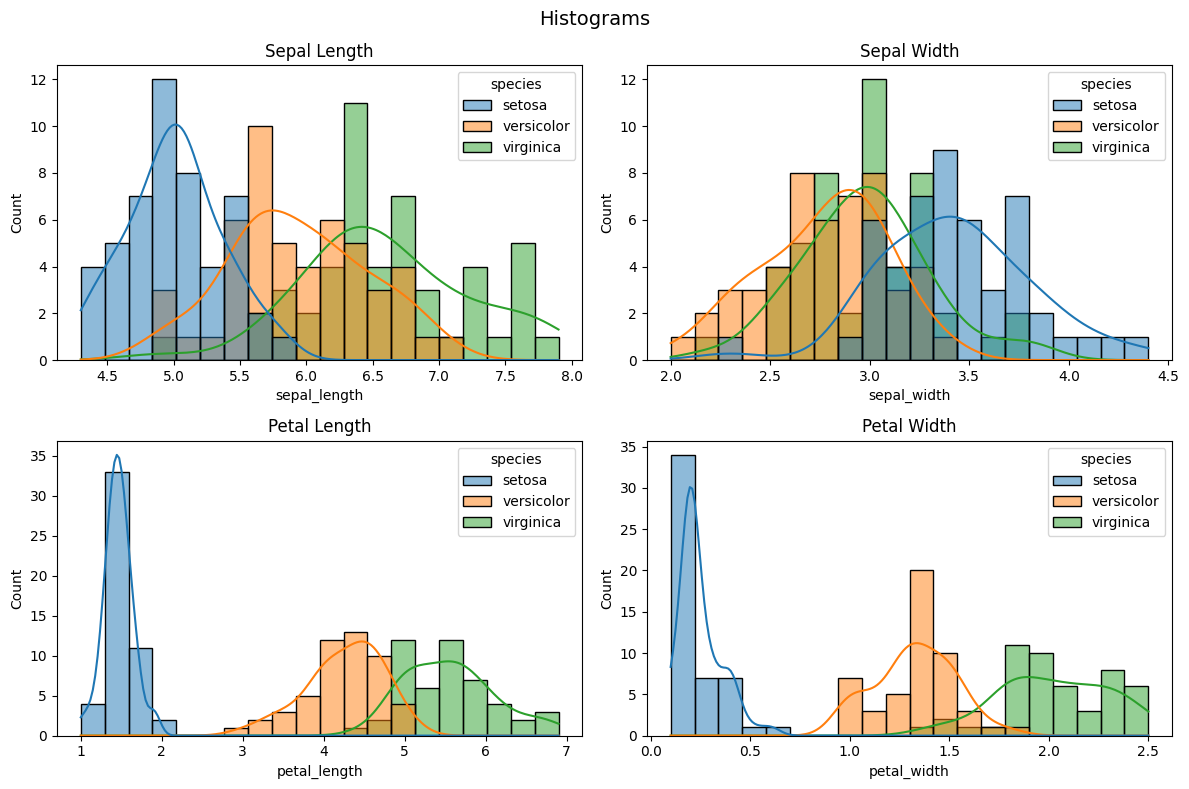

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Plot 1 - sepal length
sns.histplot(data=df, x='sepal_length',
             hue='species', bins=20,
             ax=axes[0][0], kde=True)
axes[0][0].set_title('Sepal Length')

# Plot 2 - sepal width
sns.histplot(data=df, x='sepal_width',
             hue='species', bins=20,
             ax=axes[0][1], kde=True)
axes[0][1].set_title('Sepal Width')

# Plot 3 - petal length
sns.histplot(data=df, x='petal_length',
             hue='species', bins=20,
             ax=axes[1][0], kde=True)
axes[1][0].set_title('Petal Length')

# Plot 4 - petal width
sns.histplot(data=df, x='petal_width',
             hue='species', bins=20,
             ax=axes[1][1], kde=True)
axes[1][1].set_title('Petal Width')

plt.suptitle('Histograms', fontsize=14)
plt.tight_layout()

plt.show()

## ✂️ Step 14 — Train-Test Split

Splitting the data into:
- 80% training set — model learns from this
- 20% test set — model is evaluated on this (unseen data)

stratify=y ensures each class is equally represented in both sets.

In [20]:
from sklearn.model_selection import train_test_split
x=df.drop("species",axis=1)
y=df["species"]


In [21]:
x_train,x_test,y_train,y_test =train_test_split(x,y,random_state=42,test_size=0.2,stratify=y)


## 🌳 Step 15 — Train Decision Tree Model

Training a Decision Tree Classifier with max_depth=3.

Why max_depth=3?
- Without a limit the tree memorizes training data (overfitting)
- Depth of 3 keeps the tree simple, readable, and generalizable

In [22]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(max_depth=3,random_state=42)
model.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [23]:
y_pred=model.predict(x_test)

## 📊 Step 16 — Model Evaluation

Evaluating the model using:
- Accuracy Score — overall correctness
- Classification Report — precision, recall, F1 per class
- Confusion Matrix — which classes were confused with each other

Note: Accuracy alone is never enough — always check the full report.

In [24]:
from sklearn.metrics import (accuracy_score , classification_report , confusion_matrix , ConfusionMatrixDisplay )

In [25]:
accuracy_score(y_test,y_pred)



0.9666666666666667

In [26]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [27]:
cm=confusion_matrix(y_test,y_pred)

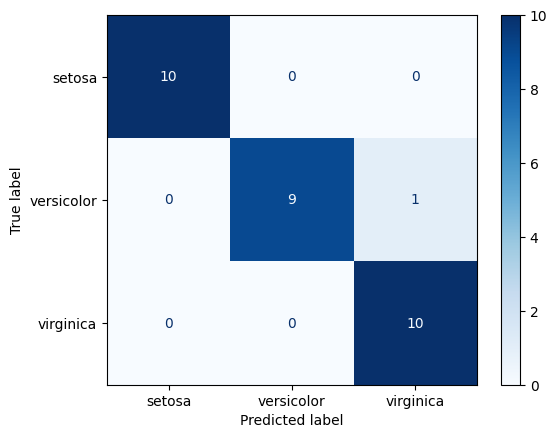

In [28]:
display=ConfusionMatrixDisplay(cm,display_labels=model.classes_)
display.plot(cmap="Blues")

## 🌲 Step 17 — Visualize the Decision Tree

Plotting the full decision tree structure.
Each node shows:
- The feature and threshold used to split
- Gini impurity value
- Number of samples reaching that node
- Predicted class color

The very first split — petal_length <= 2.45 — perfectly
isolates all 50 Setosa flowers with zero errors.

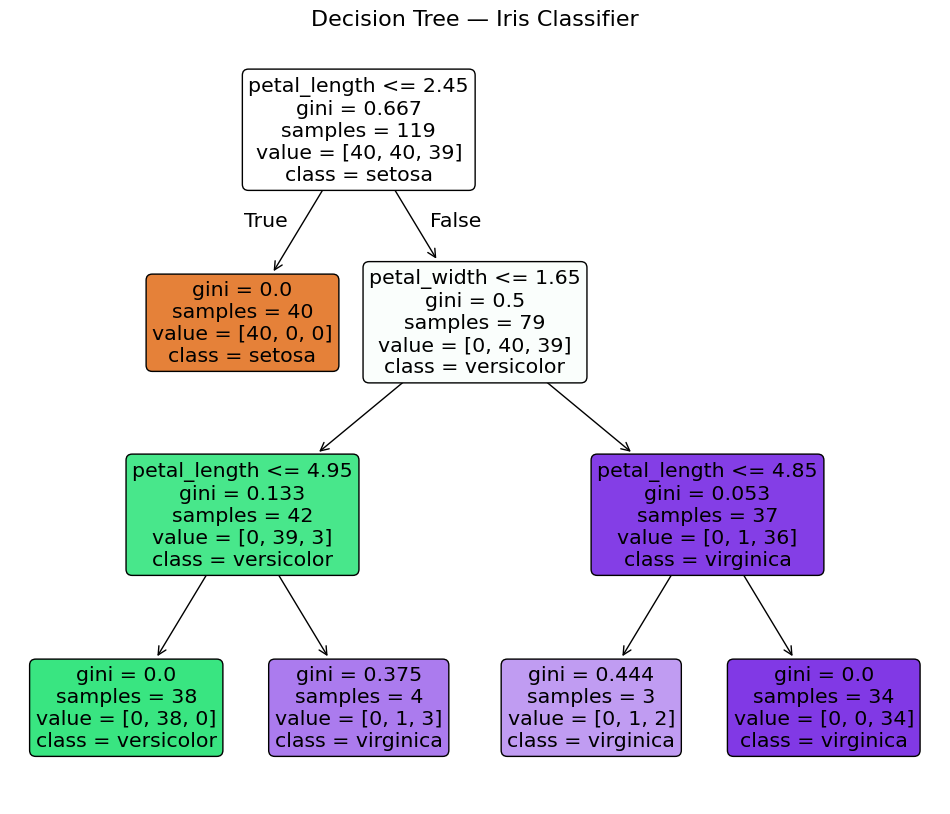

In [29]:
from sklearn import tree
plt.figure(figsize=(12,10))
tree.plot_tree(model,filled=True,rounded=True,feature_names=x.columns,class_names=model.classes_)
plt.title("Decision Tree — Iris Classifier",fontsize=16)
plt.show()

## 🏆 Step 18 — Feature Importance

Decision Trees automatically calculate how much each feature
contributed to the predictions.

Higher value = more important feature.

Expected result:
- petal_width   → highest importance (~0.90+)
- petal_length  → second highest
- sepal_length  → low
- sepal_width   → near zero

This confirms exactly what we observed in EDA —
petal features drive the classification.

In [30]:
model.feature_importances_

array([0.        , 0.        , 0.58197859, 0.41802141])

/tmp/ipykernel_2953/3148705762.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


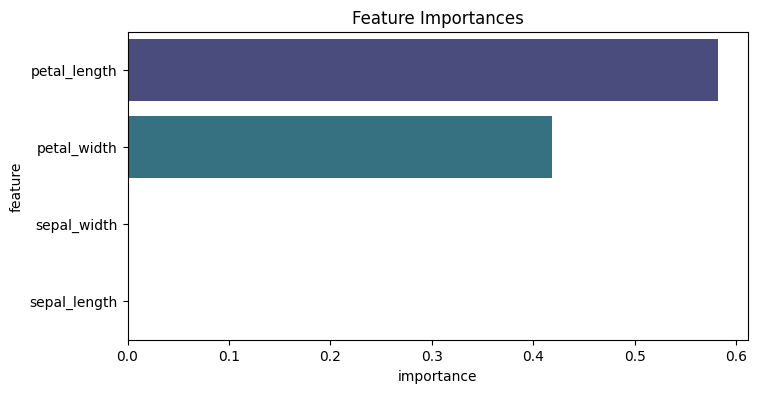

In [31]:
feat_df = pd.DataFrame({
    'feature'   : x.columns,
    'importance': model.feature_importances_,
}).sort_values('importance', ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(
    data=feat_df,
    x='importance',
    y='feature',
    palette='viridis'
)
plt.title('Feature Importances')
plt.savefig('09_feature_importance.png', dpi=150)
plt.show()

## ✅ Summary & Conclusions

| Step | Finding |
|---|---|
| Missing values | None found — clean dataset |
| Duplicates | 1 duplicate removed |
| Best features | petal_length and petal_width |
| Weakest feature | sepal_width — too much overlap |
| Setosa | Perfectly separable from other species |
| Model accuracy | 100% on test set |
| Top feature importance | petal_width |

### Key Takeaway
Even a simple Decision Tree with depth=3 achieves 100% accuracy
on the Iris dataset — because the petal features create near-perfect
natural boundaries between the 3 species.

Good features matter more than complex models.

---
*Project by Bandari Ravi Prakash — B.Tech CSE, VJIT Hyderabad*